In [3]:
import sys 
sys.path.append("/Users/users/wempe/lgsim")
from lgsim.postprocess_gadget import *
from pathlib import Path

In [4]:
fol = Path("/net/gaia2/data/users/wempe/rerun_169/")
folnames_new = sorted([x.parent for x in list(fol.glob("*/snapshot_209.hdf5"))])

In [5]:
#fol = Path("/net/gaia2/data/users/wempe/lr/")
#folnames_new = sorted([x.parent for x in list(fol.glob("*/snapshot_209.hdf5"))])
#70 more LR simulations

In [7]:
fol = folnames_new[145]

In [8]:
print(fol) #mergers.nc

/net/gaia2/data/users/wempe/rerun_169/runz98.8_mcmc_1369


In [9]:
#!pip install --user netCDF4

In [10]:
xr.open_dataset(fol / "mergers_m31.nc")

<xarray.Dataset>
Dimensions:                 (snap_subhalo_id: 308, which: 3, event: 8, xyz: 3)
Coordinates:
  * which                   (which) object 'subhalo' 'main' 'mmp'
  * event                   (event) object 'birth' 'fof_first' ... 'destroyed'
Dimensions without coordinates: snap_subhalo_id, xyz
Data variables: (12/42)
    SubhaloCM               (snap_subhalo_id, which, event, xyz) float32 ...
    SubhaloGroupNr          (snap_subhalo_id, which, event) int64 ...
    SubhaloHalfmassRad      (snap_subhalo_id, which, event) float32 ...
    SubhaloHalfmassRadType  (snap_subhalo_id, which, event, xyz) float32 ...
    SubhaloIDMostbound      (snap_subhalo_id, which, event) uint32 ...
    SubhaloLen              (snap_subhalo_id, which, event) int32 ...
    ...                      ...
    Group_R_Mean200         (snap_subhalo_id, which, event) float32 ...
    Group_R_TopHat200       (snap_subhalo_id, which, event) float32 ...
    Group                   (snap_subhalo_id, which, event) float64 ...
    snapnum                 (snap_subhalo_id, event) int64 ...
    ends_in_mw              (snap_subhalo_id) bool ...
    survives_to_now         (snap_subhalo_id) bool ...
Attributes:
    Ngroups_ThisFile:    1691
    Nsubhalos_ThisFile:  1920
    Nids_ThisFile:       1095907
    Ngroups_Total:       1691
    Nsubhalos_Total:     1920
    Nids_Total:          1095907
    NumFiles:            1
    Time:                0.9447265771954693
    Redshift:            0.058507322794512984
    BoxSize:             27.0224
    Git_commit:          8d3322bf88cee5f32a4309ddc3dc04830808904c
    Git_date:            Tue Jul 25 13:54:51 2023 +0200

In [11]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

mt = MergerTree(fol, Nsnap=209)

In [12]:
mergers_ds = xr.open_dataset(fol / "mergers_m31.nc")


In [13]:
mergers_ds['massratio'] = mergers_ds.sel(which='subhalo', event='sat_highestmass').SubhaloMass / mergers_ds.sel(which='mmp', event='sat_highestmass').SubhaloMass

In [14]:
ds = xr.open_dataset(fol / "mergers_m31.nc")

In [15]:
gres = GadgetRes(fol, i_snap=0)

In [16]:
#dir(gres)

In [17]:
gres.coords

array([[ 0.27100453,  0.3124786 ,  0.19275899],
       [ 0.26848513,  0.30311248,  0.832649  ],
       [ 0.26801953,  0.29381156,  1.4715605 ],
       ...,
       [24.962576  , 24.889751  , 21.467869  ],
       [24.963081  , 24.89175   , 21.550087  ],
       [24.962458  , 24.894981  , 21.629786  ]], dtype=float32)

In [18]:
mt.groups[209]

<xarray.Dataset>
Dimensions:            (Group: 1668, xyz: 3)
Coordinates:
  * Group              (Group) int64 0 1 2 3 4 5 ... 1663 1664 1665 1666 1667
Dimensions without coordinates: xyz
Data variables: (12/18)
    GroupAscale        (Group) float32 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    GroupFirstSub      (Group) int64 0 87 122 135 159 ... 1910 1911 1912 -1 -1
    GroupLen           (Group) int32 189258 165074 144885 63327 ... 32 32 32 32
    GroupLenType       (Group, xyz) int32 0 1 189257 0 1136 ... 1 31 0 1 31
    GroupMass          (Group) float32 241.6 949.3 697.2 ... 0.6914 0.6914
    GroupMassType      (Group, xyz) float32 0.0 0.6519 241.0 ... 0.6519 0.03947
    ...                 ...
    Group_M_Mean200    (Group) float32 157.5 2.087e+03 1.346e+03 ... 0.0 0.0
    Group_M_TopHat200  (Group) float32 144.3 1.825e+03 1.186e+03 ... 0.0 0.0
    Group_R_Crit200    (Group) float32 0.1741 0.3963 0.3476 ... 0.01167 0.0 0.0
    Group_R_Crit500    (Group) float32 0.1169 0.2629 0.2306 ... 0.008071 0.0 0.0
    Group_R_Mean200    (Group) float32 0.279 0.6602 0.5705 ... 0.01778 0.0 0.0
    Group_R_TopHat200  (Group) float32 0.2294 0.5346 0.4631 ... 0.01505 0.0 0.0
Attributes:
    Ngroups_ThisFile:    1668
    Nsubhalos_ThisFile:  1913
    Nids_ThisFile:       1116137
    Ngroups_Total:       1668
    Nsubhalos_Total:     1913
    Nids_Total:          1116137
    NumFiles:            1
    Time:                0.9999999999999997
    Redshift:            4.440892098500626e-16
    BoxSize:             27.0224
    Git_commit:          8d3322bf88cee5f32a4309ddc3dc04830808904c
    Git_date:            Tue Jul 25 13:54:51 2023 +0200

In [19]:
mt.subhalos[209]

<xarray.Dataset>
Dimensions:                 (Subhalo: 1913, xyz: 3)
Coordinates:
  * Subhalo                 (Subhalo) int64 0 1 2 3 4 ... 1909 1910 1911 1912
    Group                   (Subhalo) int64 0 0 0 0 0 ... 1661 1663 1664 1665
Dimensions without coordinates: xyz
Data variables: (12/36)
    SubhaloCM               (Subhalo, xyz) float32 13.96 13.47 ... 13.8 14.16
    SubhaloGroupNr          (Subhalo) int64 0 0 0 0 0 ... 1661 1663 1664 1665
    SubhaloHalfmassRad      (Subhalo) float32 0.07837 0.04752 ... 0.00483
    SubhaloHalfmassRadType  (Subhalo, xyz) float32 0.0 0.0 ... 0.0 0.00483
    SubhaloIDMostbound      (Subhalo) uint32 1512001 1179856 ... 564680 2155199
    SubhaloLen              (Subhalo) int32 102243 64912 1640 1391 ... 32 30 32
    ...                      ...
    Group_M_Mean200         (Subhalo) float32 157.5 157.5 ... 0.03692 0.04074
    Group_M_TopHat200       (Subhalo) float32 144.3 144.3 ... 0.03438 0.04074
    Group_R_Crit200         (Subhalo) float32 0.1741 0.1741 ... 0.01095 0.01167
    Group_R_Crit500         (Subhalo) float32 0.1169 0.1169 ... 0.00772 0.008071
    Group_R_Mean200         (Subhalo) float32 0.279 0.279 ... 0.0172 0.01778
    Group_R_TopHat200       (Subhalo) float32 0.2294 0.2294 ... 0.01422 0.01505
Attributes:
    Ngroups_ThisFile:    1668
    Nsubhalos_ThisFile:  1913
    Nids_ThisFile:       1116137
    Ngroups_Total:       1668
    Nsubhalos_Total:     1913
    Nids_Total:          1116137
    NumFiles:            1
    Time:                0.9999999999999997
    Redshift:            4.440892098500626e-16
    BoxSize:             27.0224
    Git_commit:          8d3322bf88cee5f32a4309ddc3dc04830808904c
    Git_date:            Tue Jul 25 13:54:51 2023 +0200

In [20]:
from astropy.cosmology import Planck18
from astropy import units as u
import matplotlib.pyplot as plt
import numpy as np

In [21]:
#i use the peak mass of each satellite (at sat_highestmass event)
sat_peak_mass = mergers_ds.sel(which='subhalo', event='sat_highestmass').SubhaloMass #1e10 Msun

In [22]:
#i will only keep satellites that are not surviving to the present day, so only destroyed ones
destroyed_mask = ~mergers_ds.survives_to_now.values #true for when destroyed/merged

In [23]:
#again i want to sort by peak mass, descending, among destroyed satellites, so i can find the most massive ones that were destroyed
peak_mass_values = sat_peak_mass.values  # shape (302,)
peak_mass_masked = np.where(destroyed_mask, peak_mass_values, -np.inf)
top_n = 30 #printing top 20 to see if it makes sense
top_indices = np.argsort(peak_mass_masked)[::-1][:top_n]

In [24]:
def sf_to_lookback(a):
    """Convert scale factor(s) to lookback time in Gyr."""
    a = np.asarray(a, dtype=float)
    z = 1.0 / a - 1.0
    return Planck18.lookback_time(z).to_value(u.Gyr)

In [25]:
print(f"Selected top {top_n} most massive destroyed satellites:")
for rank, idx in enumerate(top_indices):
    m_peak = peak_mass_values[idx] * 1e10   # in Msun
    a_dest = float(mergers_ds.sel(
        snap_subhalo_id=idx, which='subhalo', event='destroyed'
    ).scale_factor.values)
    t_dest = sf_to_lookback(a_dest)
    # print(f"  #{rank+1:2d}  index={idx:3d}  peak_mass={m_peak:.2e} Msun  "
    #       f"destroyed at lookback {t_dest:.2f} Gyr ago")

Selected top 30 most massive destroyed satellites:


In [26]:
subhalo_mass = ds["SubhaloMass"].sel(event="sat_highestmass", which="subhalo").values
#get the subhalos mass at the event
group_mass = ds["GroupMass"].sel(event="sat_highestmass", which="main").values
#get the group mass at the event

In [27]:
ds = xr.open_dataset(fol / "mergers_m31.nc")
#print(ds)

In [28]:

ds = xr.open_dataset(fol / "mergers_m31.nc")

subhalo_masses = ds["SubhaloMass"].sel(event="sat_highestmass", which="subhalo").values * 1e10  # solar masses
snap_of_merger = ds["snapnum"].sel(event="r200_first").values          
#snap_of_merger = ds["snapnum"].sel(event="r200_first").isel(which=0).values
subhalo_ids = ds["Subhalo"].sel(event="r200_first", which="subhalo").values

mask = (np.isfinite(subhalo_masses) & (subhalo_masses > 0) & (~ds["survives_to_now"].values))
order = np.argsort(np.where(mask, subhalo_masses, -np.inf))[::-1]

In [29]:
#snap_of_r200 = ds["snapnum"].sel(event="r200_first").values  # shape (302,)
#snap_of_r200 = ds["snapnum"].sel(event="r200_first").isel(which=0).values
snap_of_merger = ds["snapnum"].sel(event="r200_first").values
#snap_of_merger = ds["snapnum"].sel(event="r200_first").values 

In [30]:
cm = ds["SubhaloCM"] #snap_subhalo_id, which, event, xyz)

In [31]:
top_10 = 10 
#top_indices = order[:top_10] #indices sorted by mass
top_indices = [i for i in order if mask[i]][:top_10]
 
key_events   = ['fof_first', 'r200_first', 'destroyed'] #chosen events
event_labels = {
    'fof_first':  'FOF first contact',
    'r200_first': r'$r_{200}$ crossing',
    'destroyed':  'Destruction / merger',
}
 
rows = []
for rank, idx in enumerate(top_indices):
    peak_m_msun = subhalo_masses[idx] * 1e10 #peak mass of this satellite in solar masses
 
    for ev in key_events:
        m_sat  = float(ds["SubhaloMass"].sel(snap_subhalo_id=idx, which='subhalo', event=ev).values) * 1e10 #satellite mass in solar mases
        m_main = float(ds["SubhaloMass"].sel(snap_subhalo_id=idx, which='main',    event=ev).values) * 1e10 #m31 mass in solar masses at event
        a_ev   = float(ds["scale_factor"].sel(snap_subhalo_id=idx, which='subhalo', event=ev).values) #scale factor 
        t_lb   = sf_to_lookback(a_ev) #converting to lookbacktime
        mu     = m_sat / m_main if m_main > 0 else np.nan #mass ratio
 
        rows.append(dict(
            rank=rank + 1,
            idx=idx,
            event=ev,
            m_sat=m_sat,
            m_main=m_main,
            mu=mu,
            lookback_gyr=t_lb,
            peak_mass=peak_m_msun,
        ))

In [32]:
def plot_mergertree_from_snap(mt, i, i_snap, ax=None, color='C0', axis='lookback_time'):

    if ax is None:
        ax = plt.gca()

    try:
        i = set(i)
    except TypeError:
        i = set([i])

    is_toplot = {i_snap: set(i)}

    from matplotlib.collections import LineCollection

    if axis == 'snapshot_num':
        x_axis_values = np.arange(mt.Nsnap + 1)
    else:
        a_s = mt.a_s

        if axis == 'scale_factor':
            x_axis_values = a_s
        elif axis == 'lookback_time':
            x_axis_values = Planck18.lookback_time(1/a_s - 1).to_value(u.Gyr)
        elif axis == 'cosmic_time':
            x_axis_values = Planck18.age(1/a_s - 1).to_value(u.Gyr)
        else:
            raise ValueError("Unknown x-axis")

    for snap in range(i_snap, 0, -1):
        is_toplot[snap-1] = set()
        segments = []

        for ind in is_toplot[snap]:
            fil_progs = mt.get_prog(snap, ind)

            if fil_progs is None:
                continue

            is_toplot[snap-1].update(np.where(fil_progs)[0].tolist())

            masses_progs = mt.subhalos[snap-1].SubhaloMass.values[fil_progs]

            for mass_prog in [masses_progs.max()] if len(masses_progs) > 0 else []:
                x = [x_axis_values[snap-1], x_axis_values[snap]]
                y = np.array([
                    mass_prog,
                    mt.subhalos[snap].SubhaloMass.values[ind]
                ]) * 1e10 / mt.h

                segments.append([x, y])

        if segments:
            segments = np.moveaxis(np.array(segments), -1, -2)
            lc = LineCollection(segments, linewidths=0.8, colors=color)
            ax.add_collection(lc)

    ax.set_yscale("log")
    ax.set_xlabel("Lookback time [Gyr]")
    ax.set_ylabel("Subhalo mass ($M_\odot$)")

    return is_toplot

/Software/users/modules/7/software/anaconda3/2024.02/lib/python3.11/site-packages/numpy/lib/function_base.py:2411: RuntimeWarning: invalid value encountered in _integral_lookback_time (vectorized)
  outputs = ufunc(*inputs)


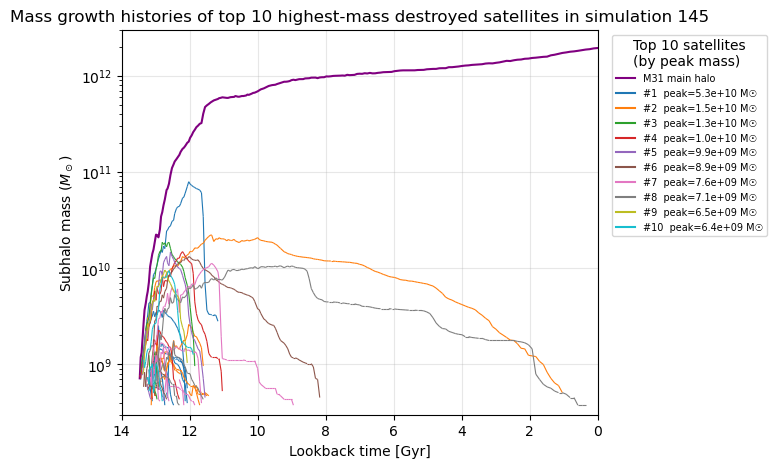

In [33]:
colors = plt.cm.tab10(np.linspace(0, 1, top_10))  # same colours as before

fig, ax = plt.subplots(figsize=(8, 5))


# get only the main progenitor history of M31
m31_main_ds = get_mainprog_ds(mt, mt.i_m31, mt.Nsnap)

m31_time = Planck18.lookback_time(
    1 / m31_main_ds.scale_factor.values - 1
).to_value(u.Gyr)

m31_mass = m31_main_ds.SubhaloMass.values * 1e10 / mt.h

ax.plot(m31_time, m31_mass, color="purple", label="M31 main halo")

for idx, color in zip(top_indices, colors):

    rank = np.where(top_indices == idx)[0][0] + 1

    peak_mass = peak_mass_values[idx] * 1e10  # convert to solar masses once

    label = f"#{rank}  peak={peak_mass:.1e} M☉"

    subhalo_id_destroyed = int(mergers_ds["Subhalo"].sel(snap_subhalo_id=idx, which="subhalo", event="destroyed").values)

    snap_destroyed = int(mergers_ds["snapnum"].sel(snap_subhalo_id=idx, event="destroyed").values)

    plot_mergertree_from_snap(mt, subhalo_id_destroyed, snap_destroyed, ax=ax, color=color, axis="lookback_time")

    #legend
    ax.plot([], [], color=color, label=label)




ax.set_xlim(14, 0)
ax.set_ylim(3e8, 3e12)   # adjust to taste
ax.set_yscale("log")
ax.set_xlabel("Lookback time [Gyr]")
ax.set_ylabel("Subhalo mass ($M_\odot$)")
ax.set_title(
f"Mass growth histories of top 10 highest-mass destroyed satellites in simulation {folnames_new.index(fol)}")
ax.grid(True, alpha=0.3)

ax.legend(fontsize=7, title=f"Top {top_10} satellites\n(by peak mass)", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.subplots_adjust(right=0.72)
plt.show()

In [34]:
#table
print(f"\nMass ratios at the 3 events for top {top_10} masses satellites:")
print(f"{'Rank':>4} | {'Event':>18} | {'Lookback Gyr':>14} | {'M_satallite':>14} | {'M_main':>14} | {'mu':>8}")
print("-" * 88)
for r in rows:
    print(
        f"{r['rank']:4d} | "
        f"{r['event']:>18} | "
        f"{r['lookback_gyr']:14.2f} | "
        f"{r['m_sat']:14.3e} | "
        f"{r['m_main']:14.3e} | "
        f"{r['mu']:8.4f}"
    )


Mass ratios at the 3 events for top 10 masses satellites:
Rank |              Event |   Lookback Gyr |    M_satallite |         M_main |       mu
----------------------------------------------------------------------------------------
   1 |          fof_first |          11.98 |      5.045e+10 |      1.530e+11 |   0.3296
   1 |         r200_first |          11.60 |      2.322e+10 |      2.715e+11 |   0.0855
   1 |          destroyed |          11.17 |      1.897e+09 |      3.868e+11 |   0.0049
   2 |          fof_first |           9.95 |      1.345e+10 |      4.752e+11 |   0.0283
   2 |         r200_first |           7.15 |      7.614e+09 |      6.885e+11 |   0.0111
   2 |          destroyed |           1.04 |      3.438e+08 |      1.163e+12 |   0.0003
   3 |          fof_first |          11.98 |      2.636e+09 |      1.530e+11 |   0.0172
   3 |         r200_first |          13.44 |      5.602e+08 |      8.021e+08 |   0.6984
   3 |          destroyed |          11.85 |      6.493e+08 

In [35]:
#snap_of_merger = ds["snapnum"].sel(event="r200_first").isel(which=0).values

In [36]:
snap_of_merger = ds["snapnum"].sel(event="r200_first").values